# Predictive Analytics Using Historical Data

## Retail Sales Forecasting

This project uses historical retail transaction data to build a predictive model for forecasting future sales trends.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importing the Dataset

The dataset contains historical retail transaction records from two different periods. The two sheets are combined into a single dataset for further analysis and sales forecasting.

In [7]:
df_2009_2010 = pd.read_excel("online_retail_II.xlsx", sheet_name = "Year 2009-2010")
df_2010_2011 = pd.read_excel("online_retail_II.xlsx", sheet_name = "Year 2010-2011")

df = pd.concat([df_2009_2010, df_2010_2011], ignore_index = True)

print("Dataset shape:", df.shape)

Dataset shape: (1067371, 8)


## 2. Data Cleaning and Preprocessing

The historical retail data is cleaned by removing duplicate records and preparing the required fields for predictive analysis.

In [8]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1033036, 8)


### Checking Missing Values

Missing values are checked to identify incomplete records before building the predictive model.

In [9]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

### Handling Missing Values

Rows with missing values in the required forecasting fields are removed to ensure that the data is suitable for sales prediction.

In [10]:
df = df.dropna(subset=["InvoiceDate", "Quantity", "Price"])

print("Missing values in required fields:")
print(df[["InvoiceDate", "Quantity", "Price"]].isnull().sum())

Missing values in required fields:
InvoiceDate    0
Quantity       0
Price          0
dtype: int64


### Calculating Sales Amount

Sales amount is calculated by multiplying the quantity of products sold by their unit price. This value will be used as the target for sales forecasting.

In [11]:
df["Sales"] = df["Quantity"] * df["Price"]

df[["Quantity", "Price", "Sales"]].head()

,Quantity,Price,Sales
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


### Converting Date Column

The invoice date is converted into a proper date format so that historical sales can be analyzed over time.

In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[us]


### Filtering Valid Sales Records

Records with non-positive quantities or prices are removed so that only valid sales transactions are used for prediction.

In [13]:
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

print("Dataset shape after preprocessing:", df.shape)

Dataset shape after preprocessing: (1007914, 9)


### Preparing Monthly Sales Data

The cleaned transaction data is aggregated by month to prepare historical sales data for time-series prediction.

In [14]:
monthly_sales = (
    df.set_index("InvoiceDate")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,InvoiceDate,Sales
0,2009-12-31,822483.950
1,2010-01-31,651155.112
2,2010-02-28,551878.296
3,2010-03-31,830915.261
4,2010-04-30,678875.252


### Historical Sales Trend

The monthly sales data is visualized to observe the historical sales trend before building the predictive model.

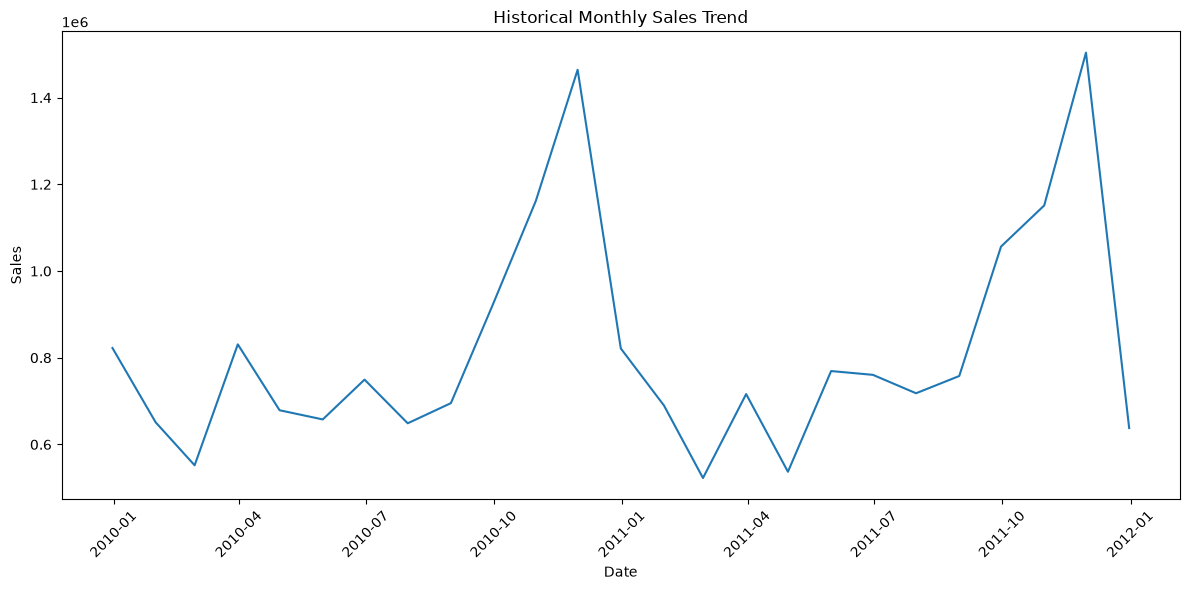

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Sales"]
)

plt.title("Historical Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Preparing Data for Prediction

A time index is created to represent the sequence of months. This feature will be used by the regression model to learn the historical sales trend.

In [16]:
monthly_sales["Time_Index"] = np.arange(len(monthly_sales))

monthly_sales.head()

,InvoiceDate,Sales,Time_Index
0,2009-12-31,822483.950,0
1,2010-01-31,651155.112,1
2,2010-02-28,551878.296,2
3,2010-03-31,830915.261,3
4,2010-04-30,678875.252,4


### Splitting Training and Testing Data

The historical sales data is divided chronologically into training and testing sets. The training data is used to build the predictive model, while the testing data is used to evaluate its accuracy.

In [17]:
train_size = int(len(monthly_sales) * 0.8)

train_data = monthly_sales.iloc[:train_size]
test_data = monthly_sales.iloc[train_size:]

X_train = train_data[["Time_Index"]]
y_train = train_data["Sales"]

X_test = test_data[["Time_Index"]]
y_test = test_data["Sales"]

print("Training data:", len(train_data))
print("Testing data:", len(test_data))

Training data: 20
Testing data: 5


## 3. Building the Predictive Model

A linear regression model is used to learn the relationship between time and historical sales and predict sales for unseen periods.

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)



## 4. Model Evaluation

The model is evaluated by comparing the predicted sales with the actual sales using Mean Absolute Error (MAE) and R-squared (R²).

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 306664.4969866166
R-squared (R²): -0.6092125855828596


## 5. Actual vs Predicted Sales

The actual and predicted sales values are visualized to compare the model's predictions with the historical test data.

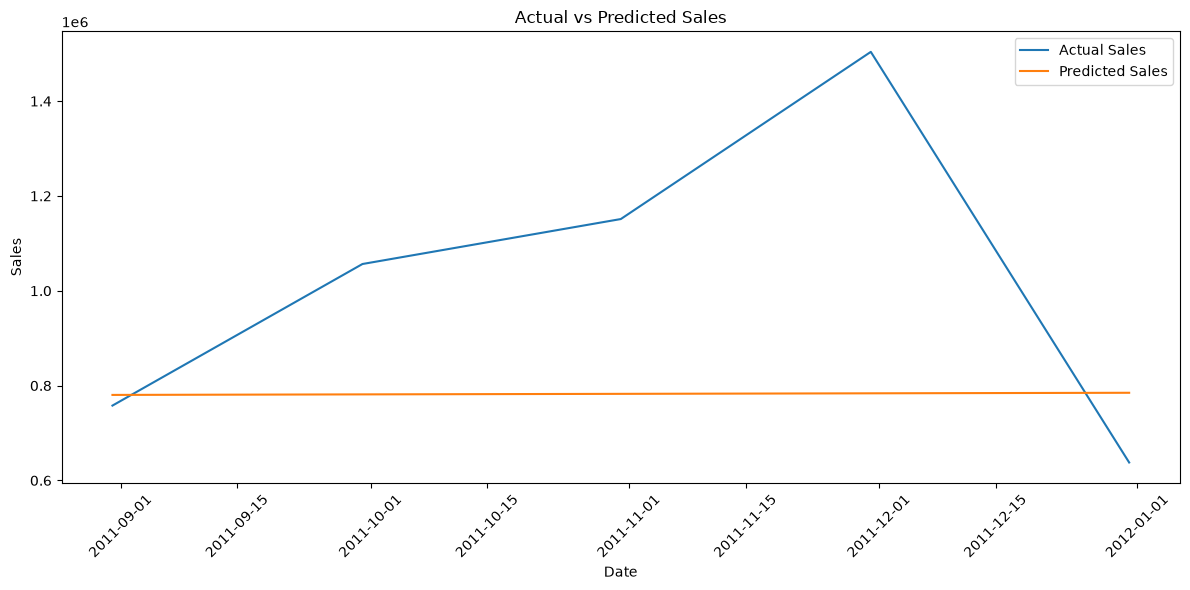

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(test_data["InvoiceDate"], y_test, label="Actual Sales")
plt.plot(test_data["InvoiceDate"], y_pred, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Future Sales Forecast

The trained regression model is used to forecast sales for the next five months based on the historical sales trend.

In [21]:
future_time = pd.DataFrame({
    "Time_Index": np.arange(
        len(monthly_sales),
        len(monthly_sales) + 5
    )
})

future_predictions = model.predict(future_time)

future_dates = pd.date_range(
    start=monthly_sales["InvoiceDate"].iloc[-1] + pd.offsets.MonthEnd(1),
    periods=5,
    freq="ME"
)

future_sales = pd.DataFrame({
    "InvoiceDate": future_dates,
    "Predicted_Sales": future_predictions
})

future_sales

,InvoiceDate,Predicted_Sales
0,2012-01-31,785982.925491
1,2012-02-29,787112.731632
2,2012-03-31,788242.537774
3,2012-04-30,789372.343915
4,2012-05-31,790502.150056


### Future Sales Forecast

The predicted sales for the next five months are visualized to show the expected future sales trend.

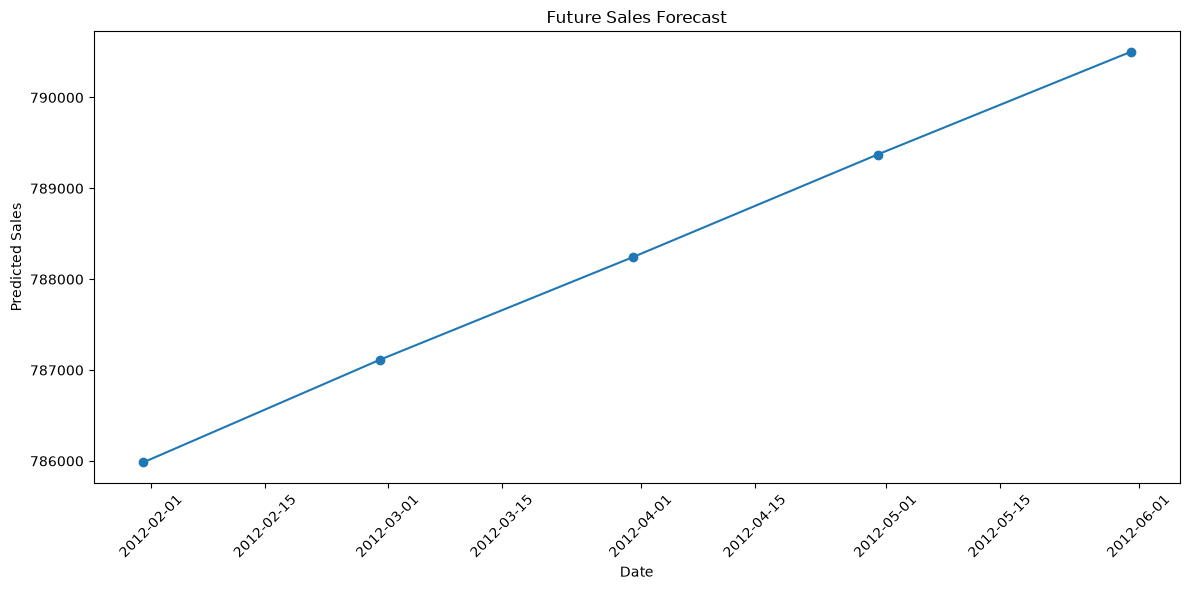

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(
    future_sales["InvoiceDate"],
    future_sales["Predicted_Sales"],
    marker="o"
)

plt.title("Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()